## <span style="color:red"> VI. Practice quiz </span>

We will use the dataset of the top 1000 movies according to imdb.com (as of 2020).

In [3]:
import pandas as pd
df = pd.read_csv("Lectures/Lec_24/files_lec24/imdb_top_1000.csv")

# Q1 

<font size = "4">

- The "Genre" column describes the category or categories of each movie in the dataset. 

- Each movie can have one or more genres. For example "The Shawshank Redemption" is classified as "Drama", while "The Dark Knight" is classified as "Action, Crime, Drama"

- One of the genres is "Animation". Using a **single Pandas method**, replace all appearances of the string "Animation" with the new string "Animated".

- For example, the 23rd ranked movie "Sen to Chihiro no kamikakushi" is originally classified as "Animation, Adventure, Family". After you perform the replacement correctly, it will be classified as "Animated, Adventure, Family". 

In [4]:
# your code here

df["Genre"] = df["Genre"].str.replace("Animation", "Animated")

display(df['Genre'])

0                         Drama
1                  Crime, Drama
2          Action, Crime, Drama
3                  Crime, Drama
4                  Crime, Drama
                 ...           
995      Comedy, Drama, Romance
996              Drama, Western
997         Drama, Romance, War
998                  Drama, War
999    Crime, Mystery, Thriller
Name: Genre, Length: 1000, dtype: object

# Q2

- Create a new DataFrame called ``df_music`` that only contains movies that are classified as "Music".

- "Music" does not have to be the only genre for each movie. For example, your DataFrame should include the 34th ranked movie "Whiplash", which is classified as "Drama, Music"

- **Using Python commands**, print the number of movies that have the "Music" classification as part of their genre.

In [5]:
# Your code here

df_music = df[df['Genre'].str.contains('Music')]
display(df_music)

print(len(df_music))

,Name,Released_Year,Length,Genre,IMDB_Rating,Overview,Director,Star1,Star2,Gross
34,Whiplash,2014,106 min,"Drama, Music",8.5,A promising young drummer enrolls at a cut-thr...,Damien Chazelle,Miles Teller,J.K. Simmons,"13,092,000"
38,The Pianist,2002,150 min,"Biography, Drama, Music",8.5,A Polish Jewish musician struggles to survive ...,Roman Polanski,Adrien Brody,Thomas Kretschmann,"32,572,577"
76,Anand,1971,122 min,"Drama, Musical",8.4,The story of a terminally ill man who wishes t...,Hrishikesh Mukherjee,Rajesh Khanna,Amitabh Bachchan,NaN
86,Andhadhun,2018,139 min,"Crime, Drama, Music",8.3,A series of mysterious events change the life ...,Sriram Raghavan,Ayushmann Khurrana,Tabu,"1,373,943"
120,Singin' in the Rain,1952,103 min,"Comedy, Musical, Romance",8.3,A silent film production company and cast make...,Stanley Donen,Gene Kelly,Gene Kelly,"8,819,028"
175,Höstsonaten,1978,99 min,"Drama, Music",8.2,A married daughter who longs for her mother's ...,Ingmar Bergman,Ingrid Bergman,Liv Ullmann,NaN
183,Some Like It Hot,1959,121 min,"Comedy, Music, Romance",8.2,"After two male musicians witness a mob hit, th...",Billy Wilder,Marilyn Monroe,Tony Curtis,"25,000,000"
207,PK,2014,153 min,"Comedy, Drama, Musical",8.1,An alien on Earth loses the only device he can...,Rajkumar Hirani,Aamir Khan,Anushka Sharma,"10,616,104"
227,Okuribito,2008,130 min,"Drama, Music",8.1,A newly unemployed cellist takes a job prepari...,Yôjirô Takita,Masahiro Motoki,Ryôko Hirosue,"1,498,210"
238,Munna Bhai M.B.B.S.,2003,156 min,"Comedy, Drama, Musical",8.1,A gangster sets out to fulfill his father's dr...,Rajkumar Hirani,Sanjay Dutt,Arshad Warsi,NaN


47


# Q3

- The "Overview" column contains a text description of each movie.

- Define a Pandas Series containing all appearances of the two words "scent" and "sent". It should **only** include cases where a match is found.

- To search for the words, use ``.str.findall`` **one time**.

- To remove the rows where no matches are found, use ``.str.len`` **one time**.

In [6]:
# your answer here
scent_sent = df["Overview"].str.findall(r'\b(?:scent|sent)\b')
scent_sent = scent_sent[scent_sent.str.len() > 0]
display(scent_sent)

32           [sent]
39           [sent]
47           [sent]
286          [sent]
300          [sent]
315          [sent]
393          [sent]
410    [sent, sent]
485          [sent]
555          [sent]
634          [sent]
680          [sent]
728          [sent]
765          [sent]
960          [sent]
Name: Overview, dtype: object

# Q4

- The "Overview" column contains a text description of each movie.

- Define a Pandas Series containing all appearances of the two words "England" and "English". It should **only** include cases where a match is found.

- To search for the words, use ``.str.findall`` **one time**.

- To remove the rows where no matches are found, use ``.str.len`` **one time**.

In [12]:
# your answer here

england_english = df["Overview"].str.findall(r'\b(?:England|English)\b')
england_english = england_english[england_english.str.len() > 0]
display(england_english)

102    [England]
116    [English]
153    [English]
263    [English]
281    [England]
338    [English]
530    [England]
594    [English]
598    [England]
832    [English]
914    [England]
Name: Overview, dtype: object

# Q5

- Using ``.str.findall`` and ``.apply``, convert all strings from the "Genre" column into **tuples** of individual words.

- For example, the top 3 ranked movies (The Shawshank Redemption, The Godfather, The Dark Knight) are classified as "Drama", "Crime, Drama", "Action, Crime, Drama", respectively. After converting to tuples, they would read:

    - ("Drama")
    - ("Crime", "Drama")
    - ("Action", "Crime", "Drama")

- Each string in the tuple should be **lowercase only**

- Save this Pandas Series of tuples as a new column to the DataFrame ``df`` with the name "tokens".

- **Warning:** There are two genres with a dash: "Sci-Fi" and "Film-Noir". Make sure that the row corresponding to "Inception" has the tuple ("action", "adventure", "sci-fi") instead of the tuple ("action", "adventure", "sci", "fi")

In [7]:
# your code here
df["tokens"] = df["Genre"].str.findall("[A-Za-z-]+")
def lower_list(lst):

    out = []

    if not isinstance(lst, list):
        return out

    for w in lst:
        out.append(w.lower())
    return out

df["tokens"] = df["tokens"].apply(lower_list)
df["tokens"]

0                         [drama]
1                  [crime, drama]
2          [action, crime, drama]
3                  [crime, drama]
4                  [crime, drama]
                  ...            
995      [comedy, drama, romance]
996              [drama, western]
997         [drama, romance, war]
998                  [drama, war]
999    [crime, mystery, thriller]
Name: tokens, Length: 1000, dtype: object

# Q6

- After Q5, the column df["tokens"] is a Pandas Series of length 1,000. Each row has a single tuple containing one or more strings.

- Create a new Pandas Series called ``genre_appearances`` where each row consists of a **single string**, one for each individual string appearing in df["tokens"].

- To be clear, the first 3 rows of df["tokens"] will be:

    |  | tokens |
    | --- | --- |
    | 0 | ("drama",) |
    | 1 | ("crime", "drama") |
    | 2 | ("action", "crime", "drama") |
    | ⋮ | ⋮ |

    while the first 6 rows of ``genre_appearances`` will be:

    |  | tokens |
    | --- | --- |
    | 0 | drama |
    | 1 | crime |
    | 1 | drama |
    | 2 | action |
    | 2 | crime |
    | 2 | drama |
    | ⋮ | ⋮ |

</br>

- Create a Pandas Series called ``genre_probs`` containing the probabilities/proportions of each genre appearing in the dataset.

- Generate a bar plot showing the probabilities/proportions of **all** genres appearing in the dataset. Add a title and label the y-axis.


In [8]:
# your code here
#genre appearances
genre_appearances = df["tokens"].explode()
display(genre_appearances)

0         drama
1         crime
1         drama
2        action
2         crime
         ...   
998       drama
998         war
999       crime
999     mystery
999    thriller
Name: tokens, Length: 2541, dtype: object

In [9]:
#genre probabilities
genre_probs = genre_appearances.value_counts(normalize = True)
display(genre_probs)

tokens
drama        0.284927
comedy       0.091696
crime        0.082251
adventure    0.077135
action       0.074380
thriller     0.053916
romance      0.049193
biography    0.042896
mystery      0.038961
animated     0.032271
sci-fi       0.026368
fantasy      0.025974
history      0.022039
family       0.022039
war          0.020071
music        0.013774
horror       0.012593
western      0.007871
film-noir    0.007477
sport        0.007477
musical      0.006690
Name: proportion, dtype: float64

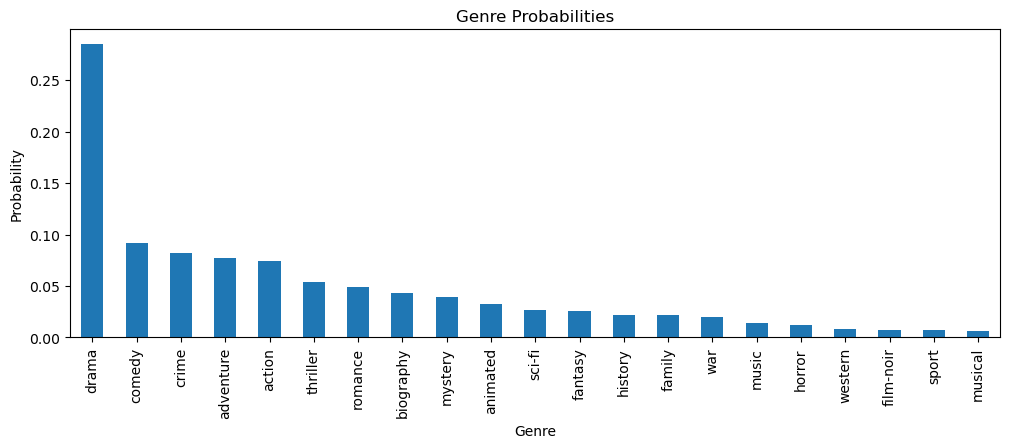

In [10]:
#bar plot of probs
import matplotlib.pyplot as plt

genre_probs.plot(kind='bar', figsize=(12,4))
plt.title("Genre Probabilities")
plt.xlabel("Genre")
plt.ylabel("Probability")
plt.show()

In [11]:
#need to know functions and methods for quiz: explode(), value_counts(), str.findall(), str.contains()
    #understand trigrams/touples to predict next word and probabilities of strings in a dataset
#LECTURES 23 AND 24